In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

DATA_PATH = r"F:\MultiDimensionalAD\data\202505161524GMT+5x30.h24.csv"

In [4]:
# load data
df = pd.read_csv(DATA_PATH)

# select features (start simple: pressure only or 4 features max)
features = [c for c in df.columns if "PI" in c]

X = df[features].values.astype("float32")

# scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
def create_sequences(X, window):
    seqs = []
    for i in range(len(X) - window):
        seqs.append(X[i:i+window])
    return np.array(seqs)

WINDOW = 24   # 24 hours (paper-scale choice)
X_seq = create_sequences(X_scaled, WINDOW)


In [6]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam


c:\Users\adith\miniconda3\envs\emerson\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\adith\miniconda3\envs\emerson\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\adith\miniconda3\envs\emerson\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the genc

In [7]:
timesteps = X_seq.shape[1]
n_features = X_seq.shape[2]

inp = Input(shape=(timesteps, n_features))

encoded = LSTM(64, activation="tanh", return_sequences=False)(inp)
latent = Dense(32, activation="tanh")(encoded)

decoded = RepeatVector(timesteps)(latent)
decoded = LSTM(64, activation="tanh", return_sequences=True)(decoded)
out = TimeDistributed(Dense(n_features))(decoded)

lstm_ae = Model(inp, out)
lstm_ae.compile(
    optimizer=Adam(1e-3),
    loss="mse"
)


In [8]:
history = lstm_ae.fit(
    X_seq, X_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    shuffle=False
)


Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0554 - val_loss: 0.0180
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0415 - val_loss: 0.0172
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0469 - val_loss: 0.0172
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0521 - val_loss: 0.0173
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0526 - val_loss: 0.0170
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0405 - val_loss: 0.0165
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0259 - val_loss: 0.0089
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0217 - val_loss: 0.0094
Epoch 9/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0188 - val_loss: 0.0087
Epoch 10/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0196 - val_loss: 0.0088
Epoch 11/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0187 - val_loss: 0.0086
Epoch 12/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 

In [10]:
from tcn import TCN


In [11]:
inp = Input(shape=(timesteps, n_features))

x = TCN(
    nb_filters=64,
    kernel_size=3,
    dilations=[1, 2, 4, 8],
    padding="causal",
    return_sequences=True
)(inp)

encoded = TCN(
    nb_filters=32,
    kernel_size=3,
    dilations=[1, 2, 4],
    padding="causal",
    return_sequences=False
)(x)

decoded = RepeatVector(timesteps)(encoded)

decoded = TCN(
    nb_filters=64,
    kernel_size=3,
    dilations=[1, 2, 4, 8],
    padding="causal",
    return_sequences=True
)(decoded)

out = TimeDistributed(Dense(n_features))(decoded)

tcn_ae = Model(inp, out)
tcn_ae.compile(
    optimizer=Adam(1e-3),
    loss="mse"
)


In [12]:
X_recon = tcn_ae.predict(X_seq)

# Euclidean distance per sequence
errors = np.linalg.norm(
    X_seq.reshape(len(X_seq), -1) -
    X_recon.reshape(len(X_recon), -1),
    axis=1
)


539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [13]:
threshold = errors.mean() + errors.std()
anomalies = errors > threshold
print(f"Number of anomalies detected: {anomalies.sum()}")

Number of anomalies detected: 2071


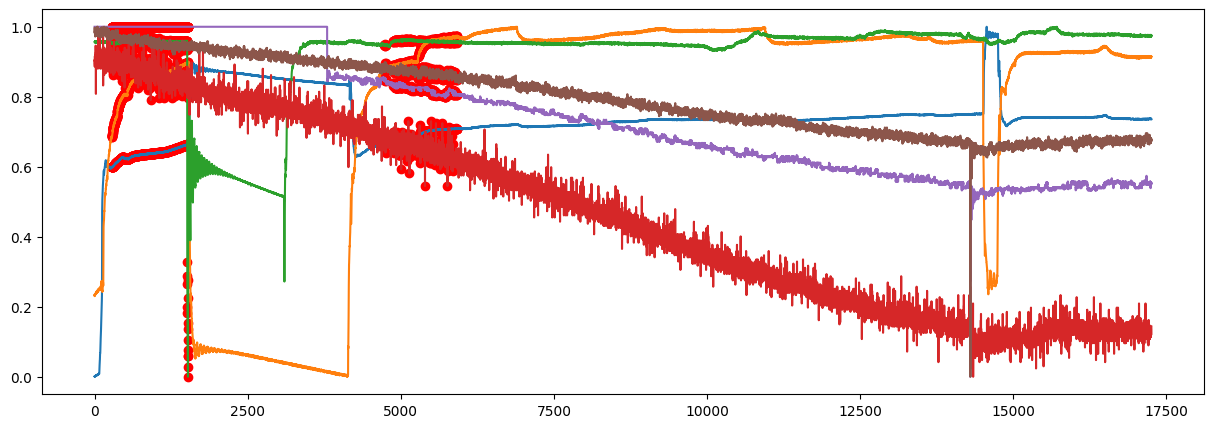

In [62]:
# plot the whole sensor with anomalies as red points
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
for i in np.random.randint(0, n_features, 6):
    plt.plot(X_scaled[:, i], label="Sensor Data")
    plt.scatter(
        np.where(anomalies)[0] + WINDOW,
        X_scaled[np.where(anomalies)[0] + WINDOW, i],
        color="red",
        label="Anomalies"
    )

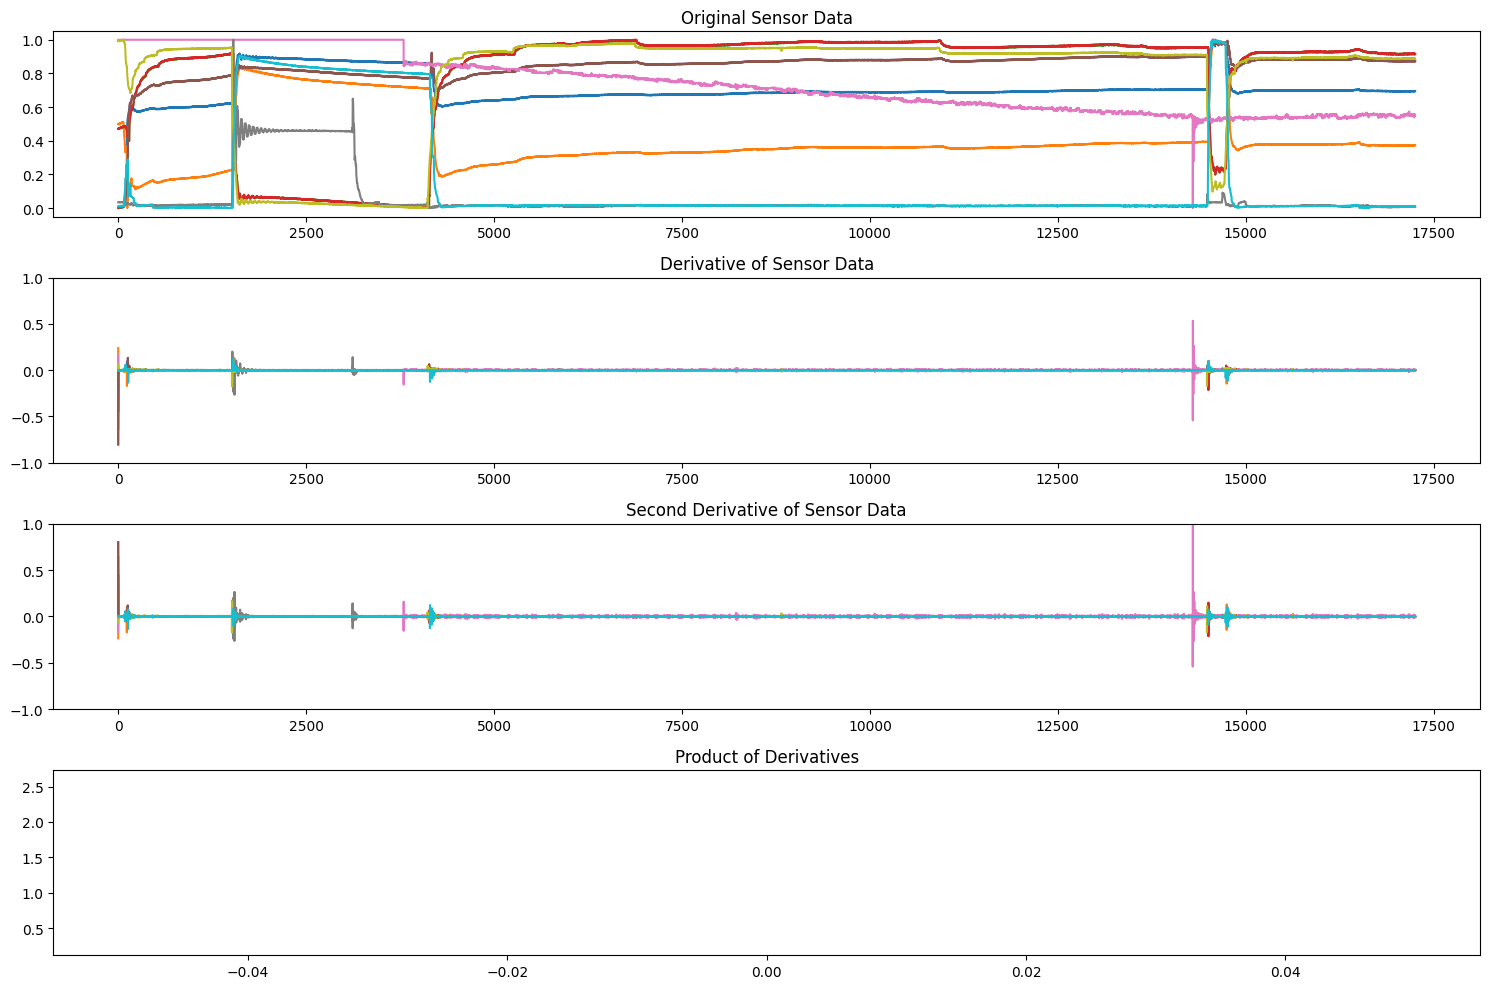

In [ ]:
# in 2 subplots plot oringal sensor vs derivative of sensor
fig, axs = plt.subplots(4, 1, figsize=(15, 10))
for i in range(10):
    axs[0].plot(X_scaled[:, i], label="Original Sensor Data")
    axs[0].set_title("Original Sensor Data")
    derivative = np.diff(X_scaled[:, i], prepend=X_scaled[5000, i])
    # adjecy plot to make y axis scale -1, 1
    axs[1].set_ylim(-1, 1)
    axs[1].plot(derivative, label="Derivative of Sensor Data")
    axs[1].set_title("Derivative of Sensor Data")
    derivative = np.diff(np.diff(X_scaled[:, i], prepend=X_scaled[5000, i]))
    axs[2].set_ylim(-1, 1)
    axs[2].plot(derivative, label="Second Derivative of Sensor Data")
    axs[2].set_title("Second Derivative of Sensor Data")
    product_derivative = derivative @ (np.diff(np.diff(X_scaled[:, i], prepend=X_scaled[5000, i])).T)
    axs[3].plot(product_derivative, label="Product of Derivatives")
    axs[3].set_title("Product of Derivatives")
plt.tight_layout()

Text(0.5, 1.0, 'First Two Principal Components of Differentials Over Time')

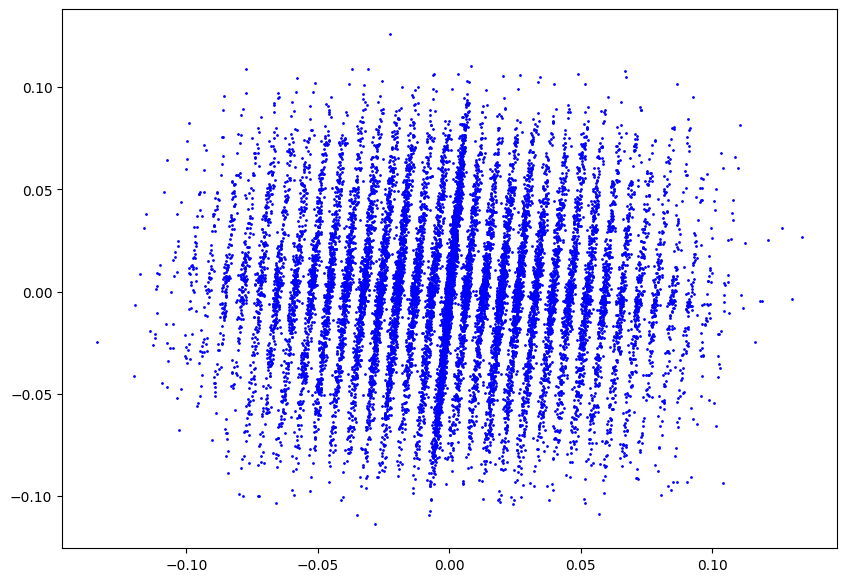

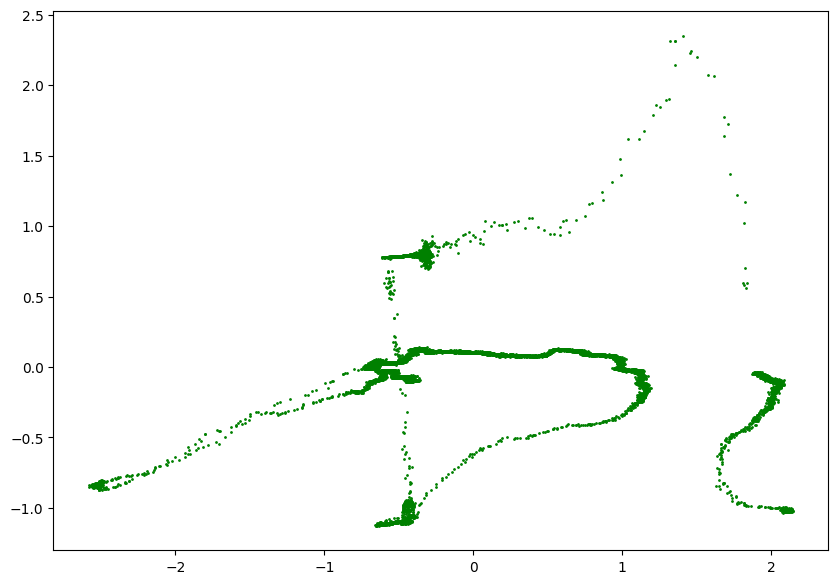

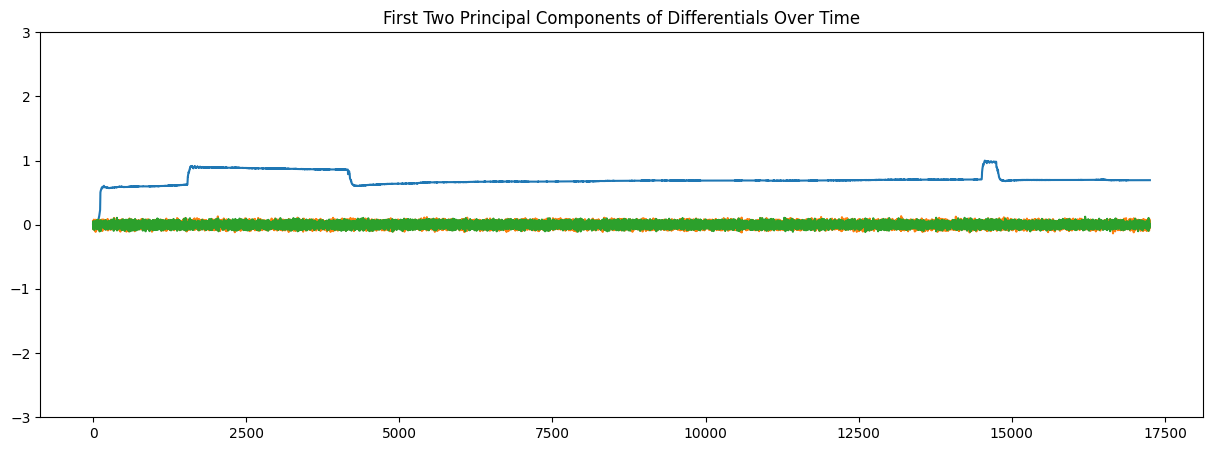

In [95]:
# apply incremental PCA on the differentials 
from sklearn.decomposition import IncrementalPCA
ipca = IncrementalPCA(n_components=5, batch_size=1000)
differentials = np.diff(X_scaled, axis=0)
differentials_ipca = ipca.fit_transform(differentials)

# plot the first 2 components of the differentials
plt.figure(figsize=(10, 7))
plt.scatter(
    differentials_ipca[:, 0],
    differentials_ipca[:, 1],
    c='blue',
    s=1
)

# apply PCA on the original data
from sklearn.decomposition import PCA
pca_model = PCA(n_components=3)
pca = pca_model.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
plt.scatter(
    pca[:, 1],
    pca[:, 2],
    c='green',
    s=1
)

# plot the pc1 and pc2 with time
plt.figure(figsize=(15, 5))
plt.ylim(-3, 3)
plt.plot(X_scaled[:, 0], label="Sensor Data")
plt.plot(differentials_ipca[:, 0], label="PC1")
plt.plot(differentials_ipca[:, 1], label="PC2")
plt.title("First Two Principal Components of Differentials Over Time")


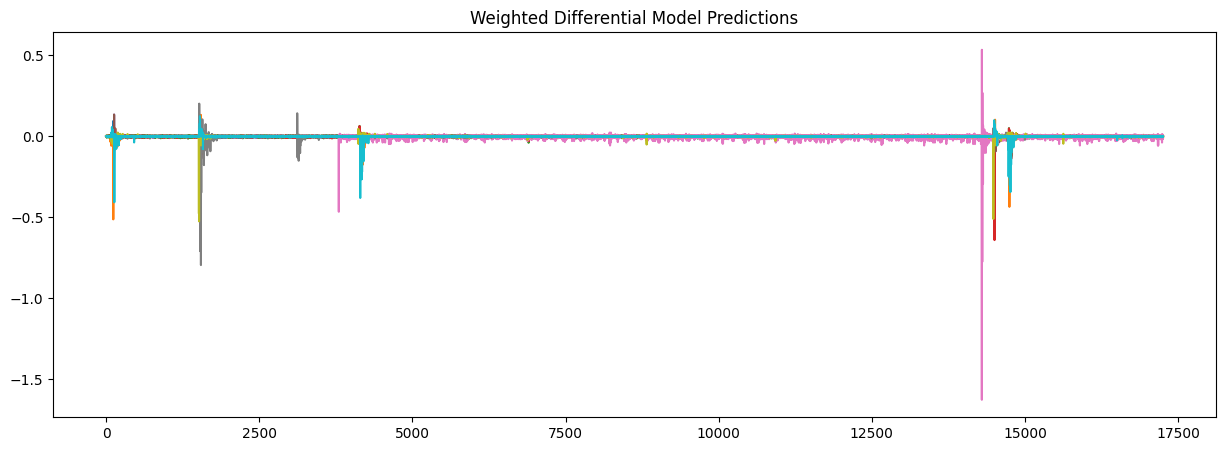

In [ ]:
# train a weighted differential model that detects drops in sensor values
class WeightedDifferentialModel:
    def __init__(self, weight=2.0):
        self.weight = weight

    def fit(self, X):
        self.X = X

    def predict(self, X):
        diffs = np.diff(X, axis=0, prepend=X[0:1])
        weighted_diffs = np.where(diffs < 0, diffs * self.weight, diffs)
        return weighted_diffs
    
    
wdm = WeightedDifferentialModel(weight=3.0)
wdm.fit(X_scaled)
wdm_preds = wdm.predict(X_scaled)
# plot wdm_preds
plt.figure(figsize=(15, 5))
for i in range(10):
    plt.plot(wdm_preds[:, i], label="WDM Predictions")
    plt.title("Weighted Differential Model Predictions")
